# Does Ride-Share Frequency Predict Regular Transit?

### Random Forest follow-up to the geography → transit memo

**Course:** PSYCH 755 · University of Wisconsin–Madison  
**Project:** CA persona / PRCA research framework  
**Notebook role:** Geo-memo follow-up — alternative predictors of regular transit  

---

#### Research question

> Does ride-share use (Q28 days; Q29 typical rides) predict whether a matched respondent takes public transportation regularly?

| Element | Specification |
|---|---|
| **Outcome** | `regular_transit`: `Q26` ∈ {`4-8 days a month`, `8 or more days a month`} |
| **Features** | `Q28`, `Q29` |
| **Model** | Balanced Random Forest + stratified 5-fold CV (`seed=42`) |
| **Benchmarks** | Chance (AUC = 0.50); geo RF (≈ 0.551); CA RF (≈ 0.590) |

Companion memo: [`memos/rideshare_predicts_transit.md`](../memos/rideshare_predicts_transit.md)  
Supporting code: [`src/ca_personas/transit_covariate_rf.py`](../src/ca_personas/transit_covariate_rf.py)  
CLI: `ca-personas covariate-transit-rf --specs rideshare`


## 1. Analytic roadmap

| Section | Content |
|---|---|
| **2. Setup** | Imports, paths, styling |
| **3. Sample** | Matched File A/B/C cohort; complete-case features |
| **4. Descriptive associations** | Regular-transit prevalence by feature level |
| **5. Random Forest CV** | ROC-AUC and classification metrics vs benchmarks |
| **6. Importances** | Gini (aggregated) + permutation importance |
| **7. Written results** | Plain-language findings for the memo |
| **8. Artifacts** | Export tables / JSON under `outputs/transit_covariate_rf/` |


## 2. Setup


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ca_personas.load import load_full_cohort
from ca_personas.paths import default_prolific_paths, default_qualtrics_path, sibling_data_available
from ca_personas.transit_covariate_rf import (
    FEATURE_SPECS,
    plot_comparison_memo_figure,
    plot_family_memo_figure,
    run_all_followup_analyses,
    run_feature_family_analysis,
    save_feature_family_artifacts,
    save_followup_bundle,
)

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})
plt.rcParams["figure.dpi"] = 120

if sibling_data_available():
    PROLIFIC = default_prolific_paths()
    QUALTRICS = default_qualtrics_path()
    source = "../sibling_data File A/B/C"
else:
    staged = Path("/tmp/sibling_data")
    PROLIFIC = [
        staged / "PRCAProlificExport_FileA.csv",
        staged / "PRCAProlificExport_FileB.csv",
    ]
    QUALTRICS = staged / "PRCAQualtricsExport_FileC.csv"
    source = "/tmp/sibling_data File A/B/C"

SEED = 42
N_SPLITS = 5
N_PERM = 30
print("Data source:", source)
print("Prolific:", [str(p) for p in PROLIFIC])
print("Qualtrics:", QUALTRICS)

SPEC_KEY = 'rideshare'
print('Spec:', SPEC_KEY, FEATURE_SPECS[SPEC_KEY])



Data source: ../sibling_data File A/B/C
Prolific: ['/tmp/sibling_data/PRCAProlificExport_FileA.csv', '/tmp/sibling_data/PRCAProlificExport_FileB.csv']
Qualtrics: /tmp/sibling_data/PRCAQualtricsExport_FileC.csv
Spec: rideshare {'features': ['Q28', 'Q29'], 'label': 'Ride-share frequency (Q28/Q29)', 'research_question': 'Does ride-share use (Q28 days; Q29 typical rides) predict whether a matched respondent takes public transportation regularly?'}


## 3. Sample & outcome


In [2]:
participants, report = load_full_cohort(
    prolific_paths=PROLIFIC,
    qualtrics_path=QUALTRICS,
    join_how="inner",
)
print("Matched analytic rows:", len(participants))
print(report)



Matched analytic rows: 241
{'n_prolific_raw': 262, 'n_prolific_unique': 262, 'n_qualtrics_raw': 273, 'n_qualtrics_with_pid': 255, 'n_qualtrics_complete_ca': 260, 'n_joined': 252, 'n_matched_both': 252, 'n_analytic': 241, 'n_dropped_missing_pid': 0, 'n_dropped_incomplete_ca': 11, 'n_dropped_unscorable_ca': 0, 'n_dropped_unjoined': 31, 'n_prolific_only': 10, 'n_qualtrics_only': 21, 'n_qualtrics_missing_pid': 18, 'waves': {'B': 153, 'A': 99}, 'notes': ['Normalized 19 DATA_EXPIRED Student status values to missing.', 'Full Prolific waves (File A/B) omit Ethnicity / Nationality / Language; demos tier uses Age, Sex, Country of residence, and Student status.', 'Analytic sample = Prolific∩Qualtrics with complete scorable PRCA group + interpersonal items.', 'Merge coverage (pre-CA filter): 252 matched Prolific∩Qualtrics; 21 Qualtrics-only (incl. 18 blank Q0 test rows; disregard); 10 Prolific-only (disregard).']}


In [3]:
analysis = run_feature_family_analysis(
    participants,
    spec_key=SPEC_KEY,
    n_splits=N_SPLITS,
    n_perm_repeats=N_PERM,
    random_state=SEED,
)
frame = analysis["frame"]
print(analysis["summary"]["secondary_rq"])
print(pd.Series(analysis["summary"]["sample"]))
frame[["participant_id", *analysis["features"], "Q26", "y"]].head()



Does ride-share use (Q28 days; Q29 typical rides) predict whether a matched respondent takes public transportation regularly?
n                233.000000
n_regular         99.000000
n_not_regular    134.000000
prevalence         0.424893
dtype: float64


,participant_id,Q28,Q29,Q26,y
0,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496...,0-1 days a month,3-4 rides in a typical day,2-4 days a month,0
1,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449...,0-1 days a month,1-2 rides in a typical day,Never,0
2,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e...,Never,1-2 rides in a typical day,Never,0
3,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d21...,Never,1-2 rides in a typical day,Never,0
4,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e0...,2-4 days a month,1-2 rides in a typical day,Never,0


## 4. Descriptive associations


,feature,level,n,n_regular,n_not_regular,pct_regular
1,Q28,2-4 days a month,65,34,31,0.523077
4,Q28,Never,62,9,53,0.145161
0,Q28,0-1 days a month,47,11,36,0.234043
2,Q28,4-8 days a month,42,29,13,0.690476
3,Q28,8 or more days a month,17,16,1,0.941176
5,Q29,1-2 rides in a typical day,206,82,124,0.398058
6,Q29,3-4 rides in a typical day,17,10,7,0.588235
7,Q29,5-6 rides in a typical day,9,6,3,0.666667
8,Q29,7 or more rides in a typical day,1,1,0,1.000000


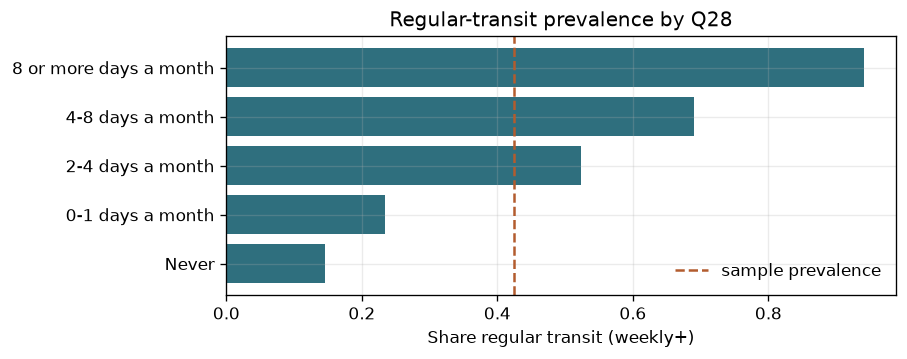

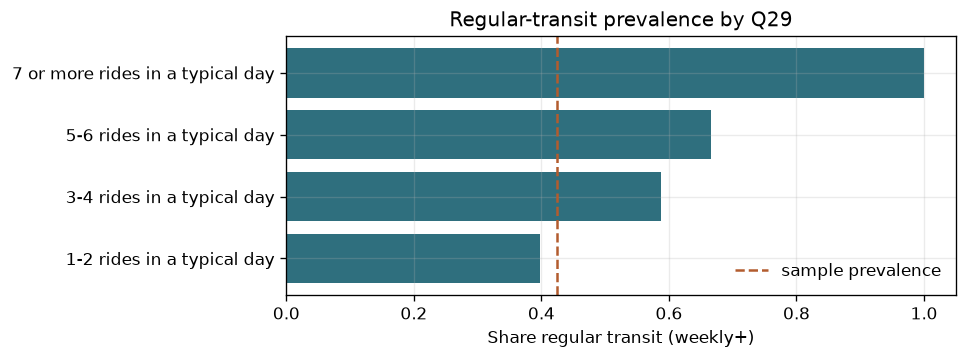

In [4]:
assoc = analysis["associations"].copy()
display(assoc)
for feat in analysis["features"]:
    sub = assoc.loc[assoc["feature"] == feat].sort_values("pct_regular")
    fig, ax = plt.subplots(figsize=(7.2, max(2.8, 0.45 * len(sub))))
    ax.barh(sub["level"].astype(str), sub["pct_regular"], color="#2F6F7E")
    ax.axvline(frame["y"].mean(), color="#B35C2E", ls="--", label="sample prevalence")
    ax.set_xlabel("Share regular transit (weekly+)")
    ax.set_title(f"Regular-transit prevalence by {feat}")
    ax.legend(frameon=False)
    plt.show()



## 5. Random Forest cross-validated performance


,model,n,roc_auc,average_precision,balanced_accuracy,f1,brier
0,random_forest_rideshare,233,0.745138,0.654822,0.731079,0.70852,0.197184
1,prevalence_prob,233,0.500000,0.424893,0.500000,0.00000,0.244359
2,majority_class,233,0.500000,0.424893,0.500000,0.00000,0.424893


Benchmarks — geo AUC 0.551 · CA AUC 0.590 · chance 0.500


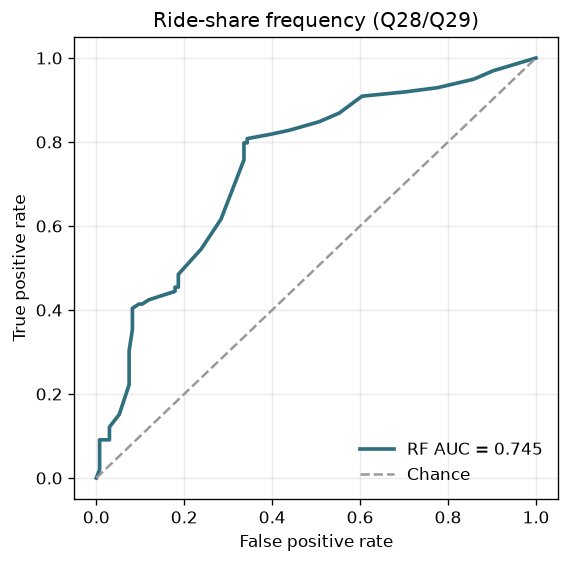

In [5]:
metrics = analysis["metrics_table"].copy()
display(metrics[["model", "n", "roc_auc", "average_precision", "balanced_accuracy", "f1", "brier"]])
print("Benchmarks — geo AUC 0.551 · CA AUC 0.590 · chance 0.500")
roc = analysis["roc"]
fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.plot(roc["fpr"], roc["tpr"], color="#2F6F7E", lw=2.2,
        label=f"RF AUC = {analysis['metrics']['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], "--", color="#999999", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(FEATURE_SPECS[SPEC_KEY]["label"])
ax.legend(frameon=False, loc="lower right")
plt.show()



## 6. Feature importances


,feature,importance_gini_sum
0,Q28,0.906433
1,Q29,0.093567


,feature,importance_perm_mean,importance_perm_std
0,Q28,0.291085,0.037258
1,Q29,0.014732,0.007175


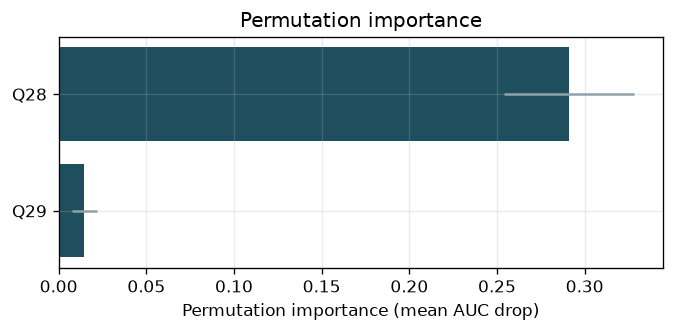

In [6]:
display(analysis["gini_raw"])
display(analysis["permutation_importance"])
perm = analysis["permutation_importance"].sort_values("importance_perm_mean")
fig, ax = plt.subplots(figsize=(6.5, max(2.5, 0.55 * len(perm))))
ax.barh(perm["feature"], perm["importance_perm_mean"], xerr=perm["importance_perm_std"],
        color="#1F4E5F", ecolor="#8FA3A8")
ax.set_xlabel("Permutation importance (mean AUC drop)")
ax.set_title("Permutation importance")
plt.show()



## 7. Written results


In [7]:
summary = analysis["summary"]
print(summary["verdict"]["interpretation"])
print()
print("Sample:", summary["sample"])
print("CV metrics:", {k: summary["cv_metrics"][k] for k in
      ["roc_auc", "average_precision", "balanced_accuracy", "f1", "brier"]})
print("Caveats:")
for c in summary["caveats"]:
    print("-", c)



Ride-share frequency (Q28/Q29) Random Forest CV ROC-AUC = 0.745. Stronger discrimination than the geo benchmark (≈0.55). Exceeds the CA-score benchmark (≈0.59).

Sample: {'n': 233, 'n_regular': 99, 'n_not_regular': 134, 'prevalence': 0.4248927038626609}
CV metrics: {'roc_auc': 0.7451379466304839, 'average_precision': 0.6548216401037097, 'balanced_accuracy': 0.731079451228705, 'f1': 0.7085201793721974, 'brier': 0.19718437562060037}
Caveats:
- Same-wave self-reports; association ≠ causal effect on transit use.
- Complete-case analysis for the listed features; N may be smaller than the full matched cohort when items are missing.
- Regular transit is a thresholded Q26 label (weekly+), not continuous ridership.


## 8. Artifacts


In [8]:
out = ROOT / "outputs" / "transit_covariate_rf" / SPEC_KEY
paths = save_feature_family_artifacts(analysis, out)
fig_path = ROOT / "memos" / "figures" / f"{SPEC_KEY}_predicts_transit_memo.png"
plot_family_memo_figure(analysis, output_path=fig_path)
print("Wrote", len(paths), "artifacts to", out)
print("Memo figure:", fig_path)



Wrote 11 artifacts to /workspace/outputs/transit_covariate_rf/rideshare
Memo figure: /workspace/memos/figures/rideshare_predicts_transit_memo.png


## 9. Limitations

- Complete-case analysis for the listed items can shrink *N* relative to the full matched cohort (especially `Q20`/`Q21`).
- Same-wave self-reports cannot establish whether mobility constraints *cause* transit use.
- The outcome is a weekly+ threshold on `Q26`, not continuous ridership intensity.
- Compare AUCs carefully across families when analytic *N* differs.
